# Gradio: Sales & Profit Visual Explorer

This notebook explains Gradio and builds a small interactive app using Pandas and Matplotlib.

**Learning goals**
- Understand what Gradio does.
- Prepare a sample DataFrame.
- Create and inspect six visualizations.
- Connect a Python function to `gr.Radio` and `gr.Plot`.
- Launch a small web interface.

## 1. Install the libraries

Run this cell if the libraries are not installed in your current Python environment.

In [1]:
%pip install gradio pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


## 2. Import libraries and create data

Gradio builds the interface, Pandas stores the table, and Matplotlib draws the charts.

In [2]:
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "Sales": [10000, 12000, 15000, 13000, 17000, 16000],
    "Profit": [2000, 3000, 4000, 2500, 3500, 3000],
}

df = pd.DataFrame(data)
df

,Month,Sales,Profit
0,Jan,10000,2000
1,Feb,12000,3000
2,Mar,15000,4000
3,Apr,13000,2500
4,May,17000,3500
5,Jun,16000,3000


### Output

The DataFrame contains six rows (one per month) and three columns: `Month`, `Sales`, and `Profit`.

## 3. Visualize the data with Matplotlib

The following cells display the expected output of each chart. PNG previews are also saved in the `images/` folder.

### Line Plot

Shows the monthly sales trend.

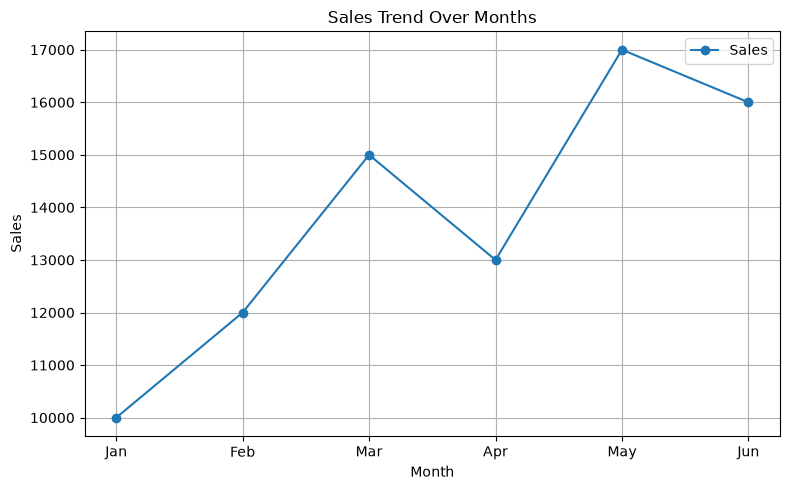

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df["Month"], df["Sales"], marker="o", label="Sales")
ax.set_title("Sales Trend Over Months")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()

### Stacked Bar Chart

Places the Profit bars above the Sales bars.

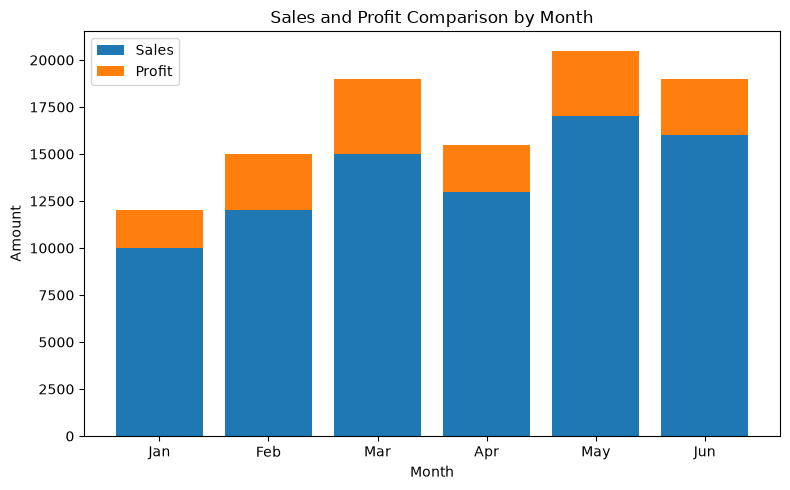

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df["Month"], df["Sales"], label="Sales")
ax.bar(df["Month"], df["Profit"], bottom=df["Sales"], label="Profit")
ax.set_title("Sales and Profit Comparison by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Amount")
ax.legend()
fig.tight_layout()
plt.show()

### Pie Chart

Shows each month's share of total profit.

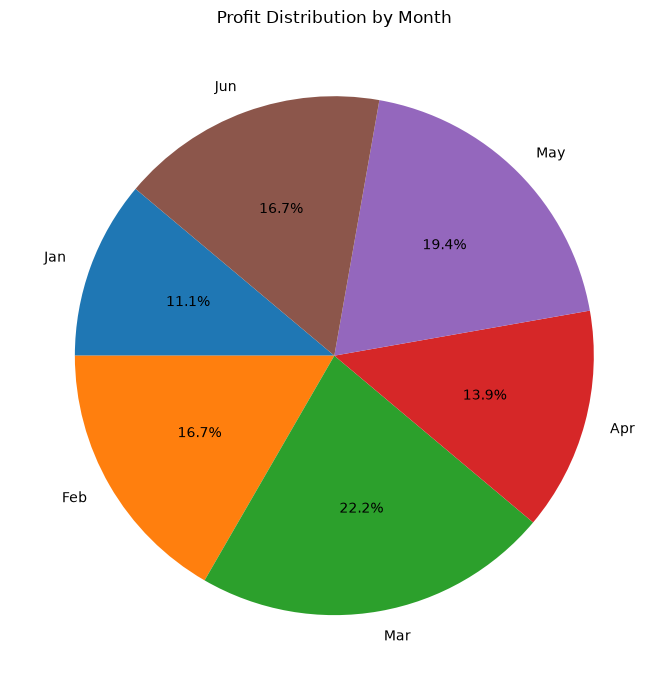

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(df["Profit"], labels=df["Month"], autopct="%1.1f%%", startangle=140)
ax.set_title("Profit Distribution by Month")
fig.tight_layout()
plt.show()

### Scatter Plot

Shows each month's Sales value against its Profit value.

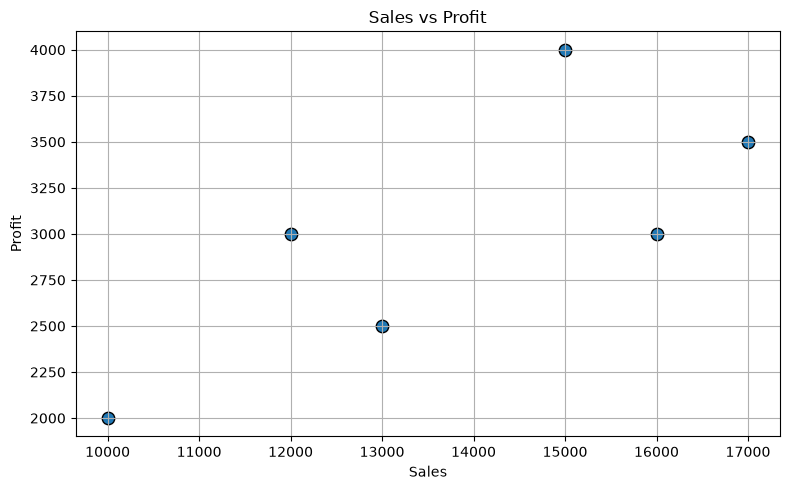

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["Sales"], df["Profit"], s=80, edgecolors="black")
ax.set_title("Sales vs Profit")
ax.set_xlabel("Sales")
ax.set_ylabel("Profit")
ax.grid(True)
fig.tight_layout()
plt.show()

### Histogram

Groups sales values into numerical ranges (bins).

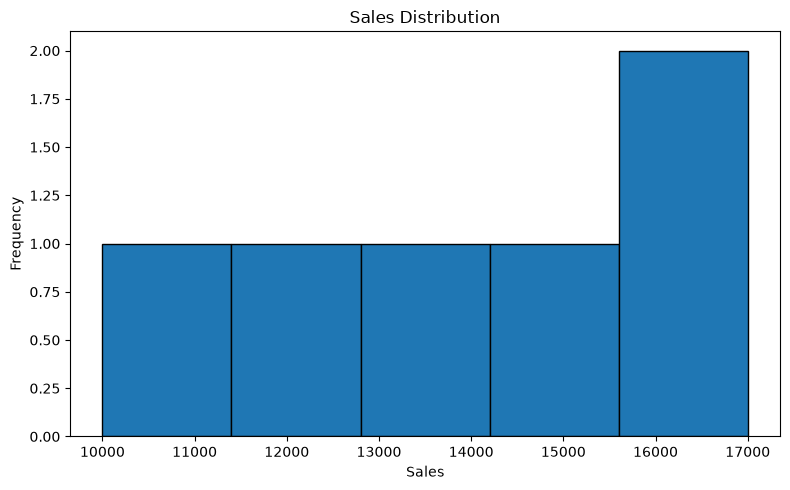

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["Sales"], bins=5, edgecolor="black")
ax.set_title("Sales Distribution")
ax.set_xlabel("Sales")
ax.set_ylabel("Frequency")
fig.tight_layout()
plt.show()

### Box Plot

Summarises the spread of the profit values.

C:\Users\zeesh\AppData\Local\Temp\ipykernel_27536\481032231.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df["Profit"], vert=False, patch_artist=True)


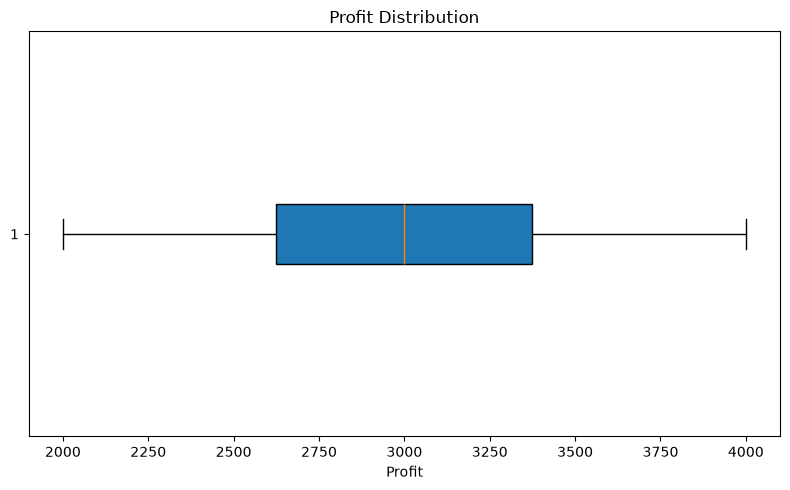

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(df["Profit"], vert=False, patch_artist=True)
ax.set_title("Profit Distribution")
ax.set_xlabel("Profit")
fig.tight_layout()
plt.show()

## 4. Define the chart-generating function

Gradio passes the selected radio-button value to `generate_plot(plot_type)`. The function returns a Matplotlib figure to the `gr.Plot` output component.

In [9]:
def generate_plot(plot_type):
    fig, ax = plt.subplots(figsize=(8, 5))

    if plot_type == "Line Plot":
        ax.plot(df["Month"], df["Sales"], marker="o", label="Sales")
        ax.set_title("Sales Trend Over Months")
        ax.set_xlabel("Month")
        ax.set_ylabel("Sales")
        ax.grid(True)
        ax.legend()

    elif plot_type == "Stacked Bar Chart":
        ax.bar(df["Month"], df["Sales"], label="Sales")
        ax.bar(df["Month"], df["Profit"], bottom=df["Sales"], label="Profit")
        ax.set_title("Sales and Profit Comparison by Month")
        ax.set_xlabel("Month")
        ax.set_ylabel("Amount")
        ax.legend()

    elif plot_type == "Pie Chart":
        ax.pie(df["Profit"], labels=df["Month"], autopct="%1.1f%%", startangle=140)
        ax.set_title("Profit Distribution by Month")

    elif plot_type == "Scatter Plot":
        ax.scatter(df["Sales"], df["Profit"], s=80, edgecolors="black")
        ax.set_title("Sales vs Profit")
        ax.set_xlabel("Sales")
        ax.set_ylabel("Profit")
        ax.grid(True)

    elif plot_type == "Histogram":
        ax.hist(df["Sales"], bins=5, edgecolor="black")
        ax.set_title("Sales Distribution")
        ax.set_xlabel("Sales")
        ax.set_ylabel("Frequency")

    elif plot_type == "Box Plot":
        ax.boxplot(df["Profit"], vert=False, patch_artist=True)
        ax.set_title("Profit Distribution")
        ax.set_xlabel("Profit")

    fig.tight_layout()
    return fig

## 5. Build the Gradio interface

- `gr.Interface()` connects a function to an interface.
- `fn` identifies the function to call.
- `gr.Radio()` provides the chart options.
- `gr.Plot()` displays the returned Matplotlib figure.
- `demo.launch()` starts the local web app.

Run the next cell when you are ready to launch the interface. Gradio will print a local URL.

In [10]:
demo = gr.Interface(
    fn=generate_plot,
    inputs=gr.Radio(
        [
            "Line Plot",
            "Stacked Bar Chart",
            "Pie Chart",
            "Scatter Plot",
            "Histogram",
            "Box Plot",
        ],
        label="Choose Plot Type",
        value="Line Plot",
    ),
    outputs=gr.Plot(label="Visualization"),
    title="Sales & Profit Visual Explorer",
    description="Choose a chart type to visualize the sample monthly sales and profit data.",
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## 6. Expected interface output

The browser interface contains:
1. The title **Sales & Profit Visual Explorer**.
2. A **Choose Plot Type** radio control with six options.
3. A **Visualization** area showing the selected chart.

Static chart previews are stored in `images/`. The live interface is interactive; change the radio selection to see another plot.

## Points to Remember

- Gradio connects a Python function to a browser interface.
- Inputs collect user selections; outputs show the function's returned result.
- `gr.Radio()` allows one selection from a list.
- `gr.Plot()` displays Matplotlib figures.
- `demo.launch()` starts the app.
- The example dataset is for practice, not real business reporting.